In [1]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t
import itertools as it
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib import rcParams

rcParams['font.size'] = 11
rcParams['axes.titlesize'] = 11

#prefix_list = ['UQ_20231118', 'UQ_20231119', 'UQ_20240107', 'UQ_20240112', 'UQ_20240111']
prefix_list = ['UQ_20231118', 'UQ_20240107', 'UQ_20240112'] # this combination works best!
N_list = [4000, 4000, 4000, 4000, 4000]
BLOCK_LIST = [200, 200, 200, 200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE'] # , 'TOTSOMC']

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collection_sim = {}

for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    ##collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collection_sim[prefix] = collect

In [3]:
collection_sim[prefix].shape, collection_sim.keys()

((4000, 15, 2, 4),
 dict_keys(['UQ_20231118', 'UQ_20240107', 'UQ_20240112', 'UQ_20240113']))

In [4]:
# Get the parameters
def get_params(prefix, parname, N, ensemble_members = None):
#    prefix = 'UQ_20240311'
#    parname = 'kmin_nuptake'
#    N = 2000
    uqroot = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC')
    if ensemble_members is None:
        ensemble_members = range(1, N+1)
    N = len(ensemble_members)
    count = 0
    for b in ensemble_members:
        hr = xr.open_dataset( os.path.join(uqroot, f'g{b:05d}', f'clm_params_{b:05d}.nc') )
        parvals = hr[parname].values
        hr.close()
        if count == 0:
            if parvals.shape == ():
                parcollect = np.full([N, 1], np.nan)
            else:
                parcollect = np.full([N, len(parvals)], np.nan)
        if parvals.shape == ():
            parcollect[count, 0] = parvals
        else:
            parcollect[count, :] = parvals.reshape(-1)
        count = count + 1
    return parcollect

In [5]:
collection_obs = uq_get_obs(VAR_LIST)
collection_obs

mean    mean_std      slope  slope_std
Variable                CO2                                                
AGBiomass_Spruce        amb   1011.342516    6.312961 -22.630105  15.609176
                        elev  1050.406404    5.474356   0.764225  14.945311
AGBiomass_Tamarack      amb    279.579613    1.925783   0.964715   5.351671
                        elev   254.434227    1.336346   2.832562   3.505693
AGBiomass_Shrub         amb    270.340560    5.762724  14.201267  15.223928
                        elev   302.026760    5.081797  11.058754  13.301223
AGNPPtoBiomass_Spruce   amb      0.085801    0.001553  -0.006844   0.003567
                        elev     0.106010    0.000945   0.002045   0.002475
AGNPPtoBiomass_Tamarack amb      0.139133    0.001688   0.002246   0.004632
                        elev     0.158908    0.003439   0.003056   0.009326
AGNPPtoBiomass_Shrub    amb      0.339493    0.004989   0.005989   0.013726
                        elev     0.386659    0.004235   0.009616   0.011041
AGNPP_Spruce            amb    103.087277   60.941097  -5.427269   4.189047
                        elev    95.461963   56.433315   0.582514   3.109720
AGNPP_Tamarack          amb     37.379727   16.385634  -0.525548   1.819285
                        elev    32.237353   14.131443   0.905672   1.490317
AGNPP_Shrub             amb     83.706280   31.810204   4.888405   4.000128
                        elev   111.648920   42.429014   7.450332   4.166588
NPP_moss                amb     93.539700   30.130576 -10.250541   3.237914
                        elev    64.657760   20.827259  -6.800788   3.995419
BGNPP_TreeShrub         amb     75.163750  106.113529   6.770230   2.220529
                        elev    79.211250  111.827647  10.162000   2.957010
BGtoAG_TreeShrub        amb      0.416775    0.007118   0.021004   0.018344
                        elev     0.323999    0.006255   0.033395   0.012219
NPP                     amb    399.084674  131.004306 -10.539866   5.995284
                        elev   383.217246  134.624795  12.299730   6.576547
HR                      amb    429.644529   80.463463  20.084135   4.317464
                        elev   460.730872   86.285287  22.430646   4.537966
NEE                     amb    174.324416    5.406817  29.397569  10.000740
                        elev   210.644919    5.108903  26.863250  10.121259

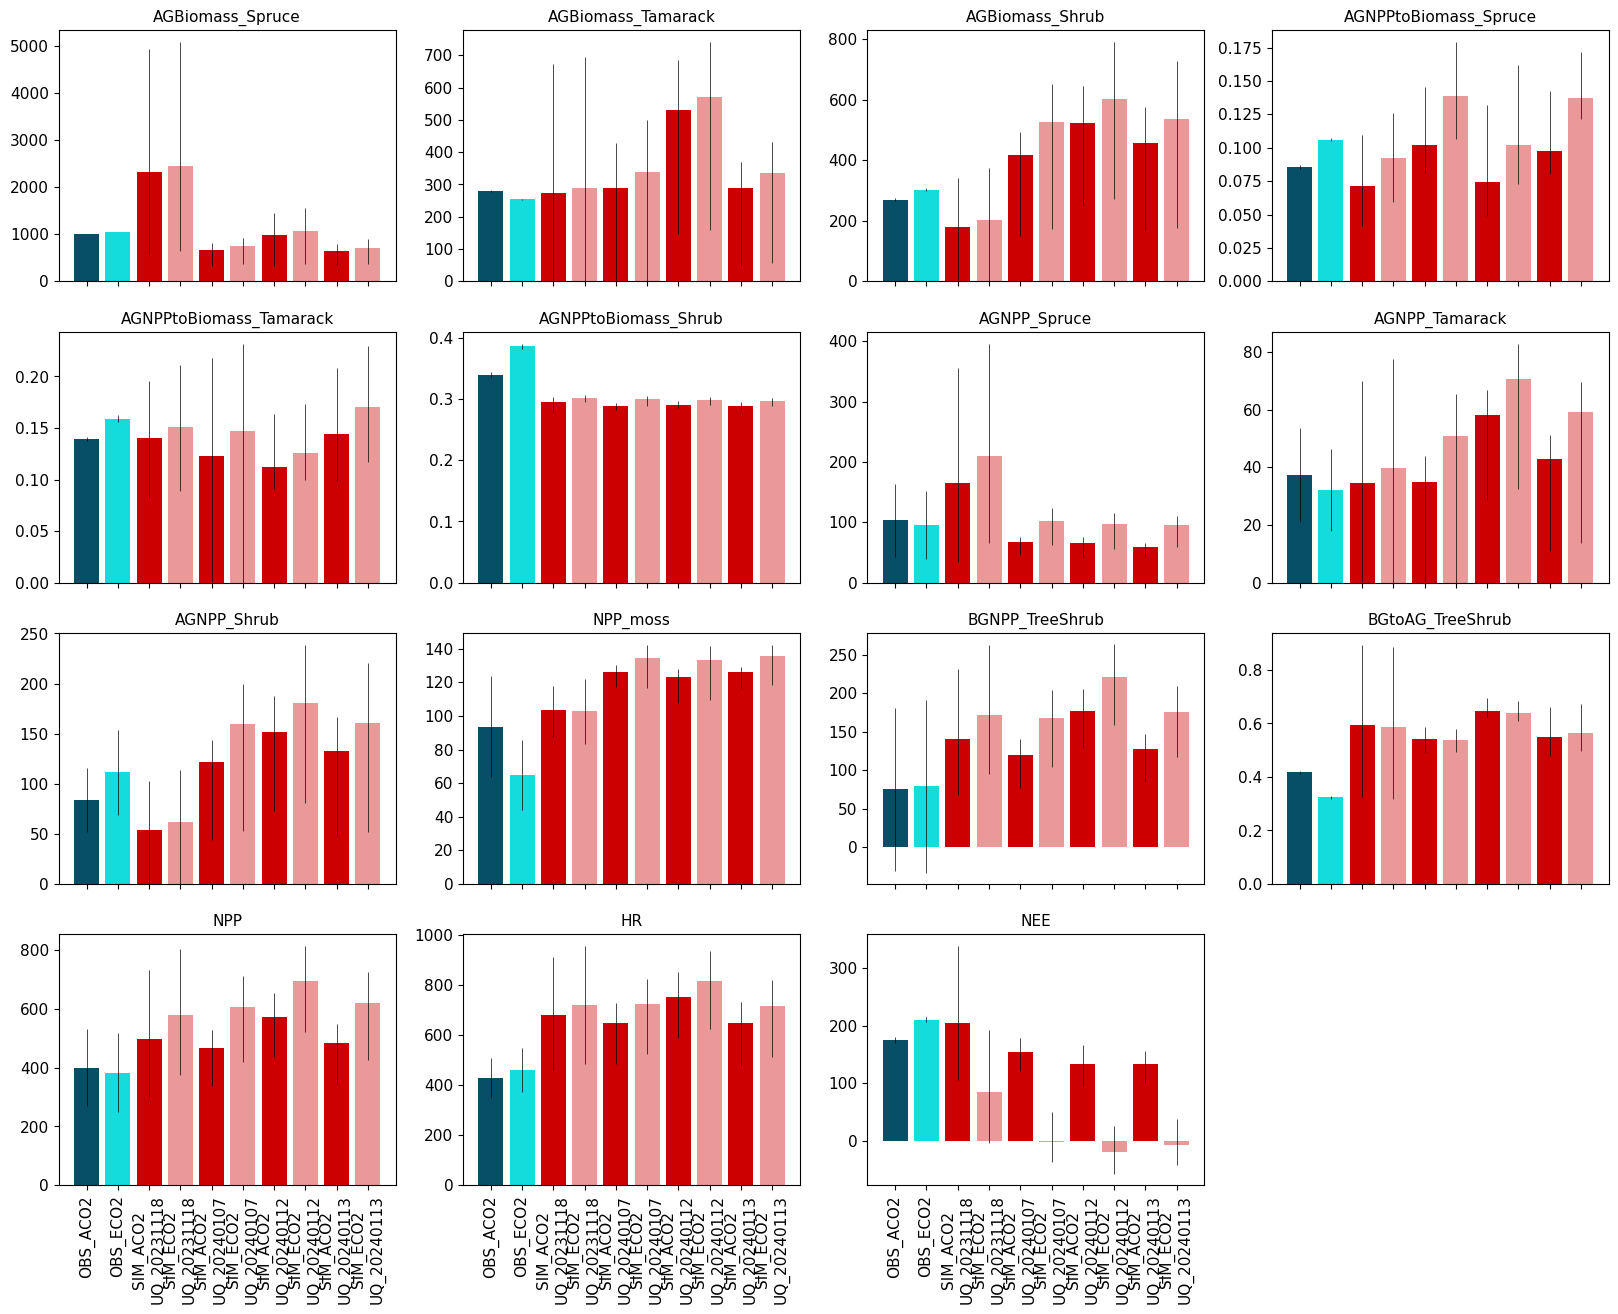

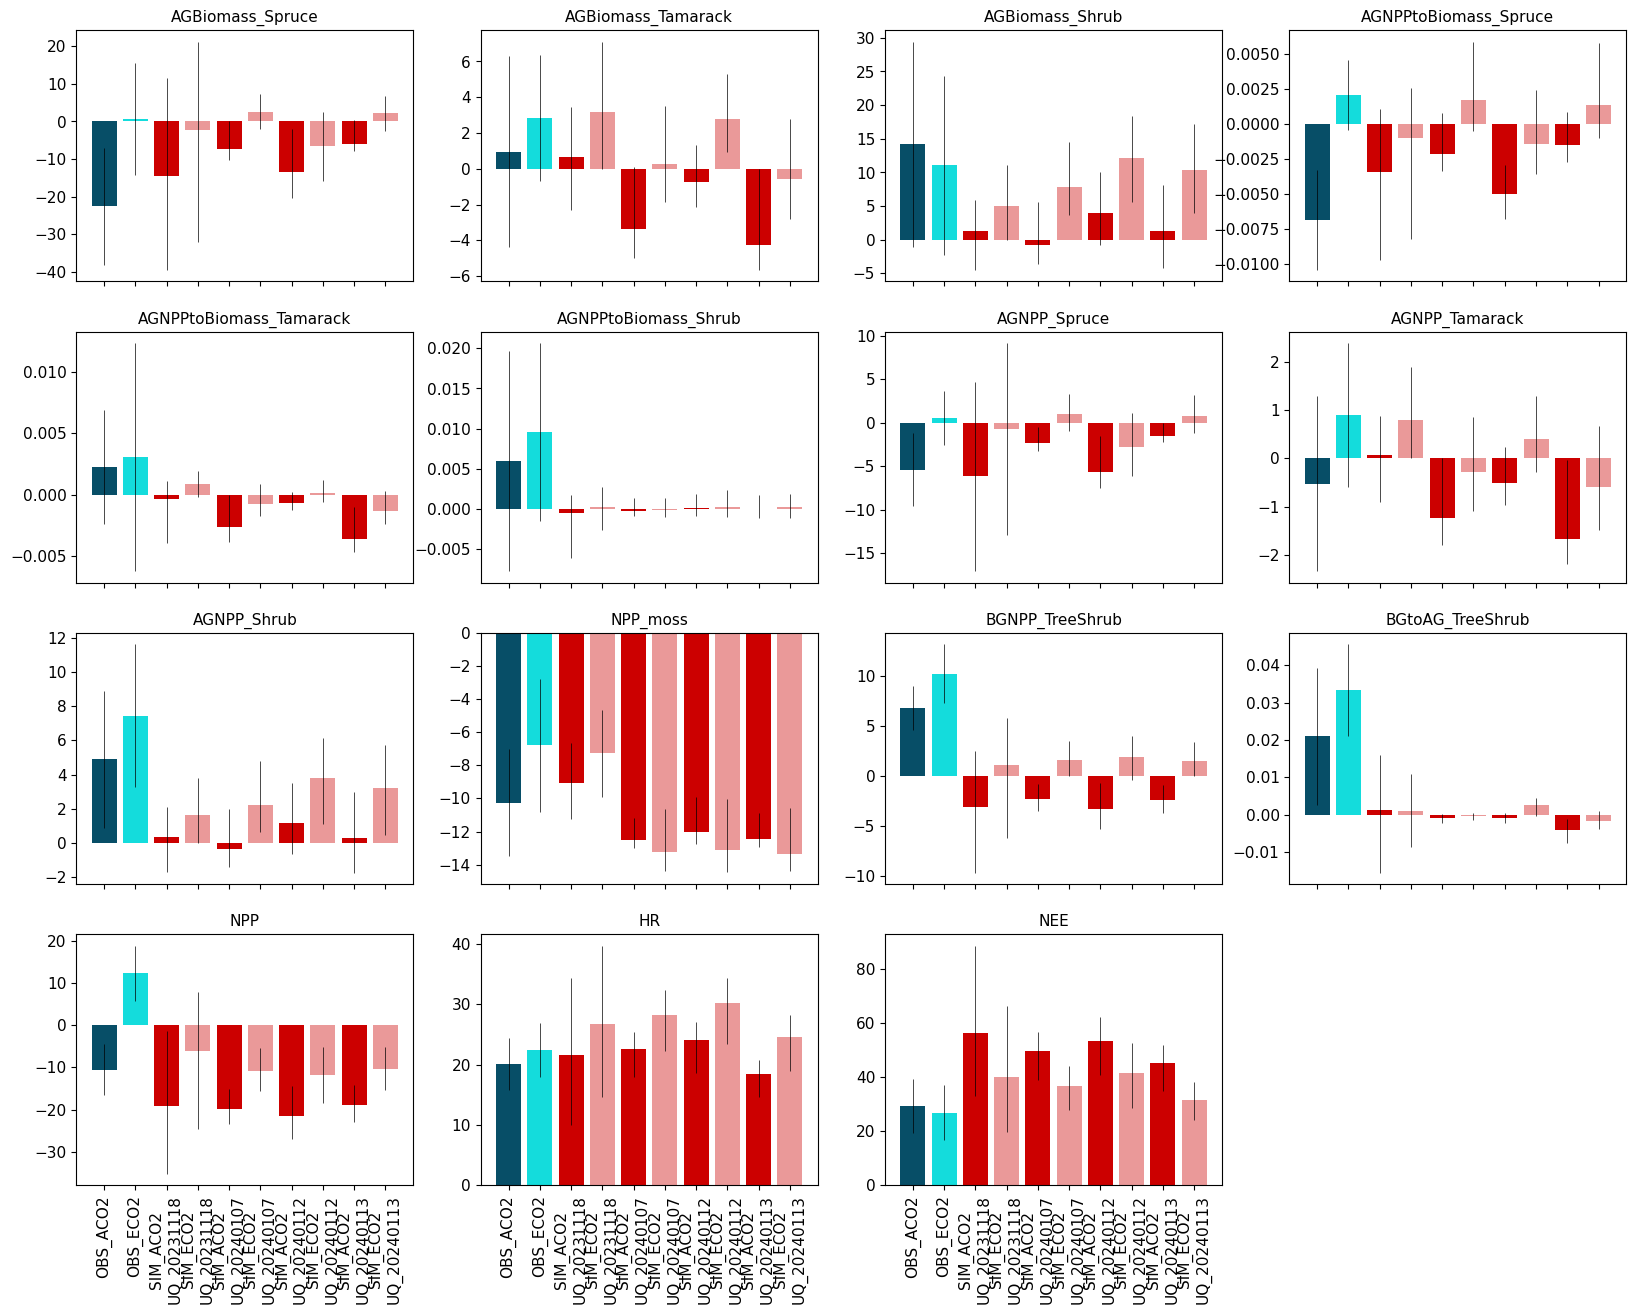

In [6]:
for quantity in ['mean', 'slope']:
    fig, axes = plt.subplots(4, 4, figsize = (20, 15), sharex = True, sharey = False)
    for i, ax in enumerate(axes.flat):
        if i >= len(VAR_LIST):
            ax.axis('off')
        else:
            varname = VAR_LIST[i]

            ax.bar([1, 2], collection_obs.loc[varname, quantity].values, 
                   color = ['#074e67', '#14dcdc'])
            ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, 
                        collection_obs.loc[varname, f'{quantity}_std'].values, 
                        ecolor = 'k', lw = 0, elinewidth = 0.5)
            ax.set_title(varname)

            if quantity == 'mean':
                k = 0
            else:
                k = 2

            for j, prefix in enumerate(prefix_list):
                temp = np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0)
                temp_q5 = np.nanpercentile(collection_sim[prefix][:, i, :, k], 5, axis = 0)
                temp_q95 = np.nanpercentile(collection_sim[prefix][:, i, :, k], 95, axis = 0)

                ax.bar([3+j*2, 4+j*2], temp, color = ['#cc0000', '#ea9999'])
                ax.errorbar([3+j*2, 4+j*2], temp, [temp - temp_q5, temp_q95 - temp], 
                            ecolor = 'k', lw = 0, elinewidth = 0.5)

        if i >= 5:
            ax.set_xticks(range(1, 3 + 2 * len(prefix_list)))
            ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])

        plt.setp(ax.get_xticklabels(), rotation = 90)

In [7]:
prefix_of_interest = 'UQ_20231118'
#prefix_of_interest = 'UQ_20240101'
#prefix_of_interest = 'UQ_20240102'
#prefix_of_interest = 'UQ_20240107'
#prefix_of_interest = 'UQ_20240112'

VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
ind_list = []
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# the 2 is ACO2 and ECO2
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
# (std across chambers)
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 1].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
# (std based on scipy.stats.lingress function's returned std)
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 3].reshape(1,-1)

sim_mean = collection_sim[prefix_of_interest][:,ind_list,:,:][:,:,:,0].reshape(-1, 2*len(ind_list))
sim_slope = collection_sim[prefix_of_interest][:,ind_list,:,:][:,:,:,2].reshape(-1, 2*len(ind_list))

# subset to the top 1% best (40 runs), then pick the one with highest shrub performance
# It is the belowground criteria that messes up my RMSE!
rmse_weights = np.repeat(np.array([1, 1, 1, 1, 1, 1, 1]), 2).reshape(1,-1)
#rmse_mean = np.mean((np.abs(sim_mean - obs_mean) / np.abs(obs_mean))*rmse_weights, axis = 1)
rmse_mean = np.mean((np.abs(sim_mean - obs_mean) / obs_mean_std)*rmse_weights, axis = 1)
#rmse_slope = np.mean((np.abs(sim_slope - obs_slope) / np.abs(obs_slope))*rmse_weights, axis = 1)
rmse_slope = np.mean((np.abs(sim_slope - obs_slope) / obs_slope_std)*rmse_weights, axis = 1)
rmse_tot = rmse_mean + rmse_slope
n_best_ind = 40
best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

#rmse_mean_2 = np.mean((np.abs(sim_mean[best_inds,:] - obs_mean) / \
#                       np.abs(obs_mean))*rmse_weights, axis = 1)
#rmse_slope_2 = np.mean((np.abs(sim_slope[best_inds] - obs_slope) / \
#                        np.abs(obs_slope))*rmse_weights, axis = 1)
rmse_mean_2 = np.mean((np.abs(sim_mean[best_inds,:] - obs_mean) / \
                       obs_mean_std)*rmse_weights, axis = 1)
rmse_slope_2 = np.mean((np.abs(sim_slope[best_inds] - obs_slope) / \
                       obs_slope_std)*rmse_weights, axis = 1)

rmse_tot_2 = rmse_mean_2 + rmse_slope_2
best_ind = best_inds[np.nanargmin(rmse_tot_2)]

print(f'top {n_best_ind} best rmses = ', rmse_tot[best_inds])
print(f'top {n_best_ind} best runs = ', best_inds + 1)
print('best rmse = ', rmse_tot[best_ind])
print('best run = ', best_ind + 1)

top 40 best rmses =  [1.85393643 1.76650974 1.81098764 1.8768435  1.85535266 1.82941324
 1.87192674 1.71458811 1.8074213  1.86416344 1.86032558 1.81873894
 1.76518143 1.85441815 1.84810802 1.81720112 1.6165109  1.73837779
 1.83436456 1.86620199 1.6058501  1.76507104 1.71934105 1.82914592
 1.79513514 1.66268207 1.79979336 1.71289942 1.7955714  1.74319108
 1.88136805 1.88340364 1.88714337 1.88739571 1.88817779 1.88719134
 1.88880881 1.89131398 1.89348909 1.8998628 ]
top 40 best runs =  [1903  823 2598 2028 3796 3165 2526 2691 3453 1534 3108 2472  231 1196
  907 3620 1181  262 2848 3613 3067 2562 1125 1757 1679 1682 2154   98
 1103 3003  694 3661  652  709 3711  255 1660 3767 3564 1130]
best rmse =  1.6058501003728596
best run =  3067


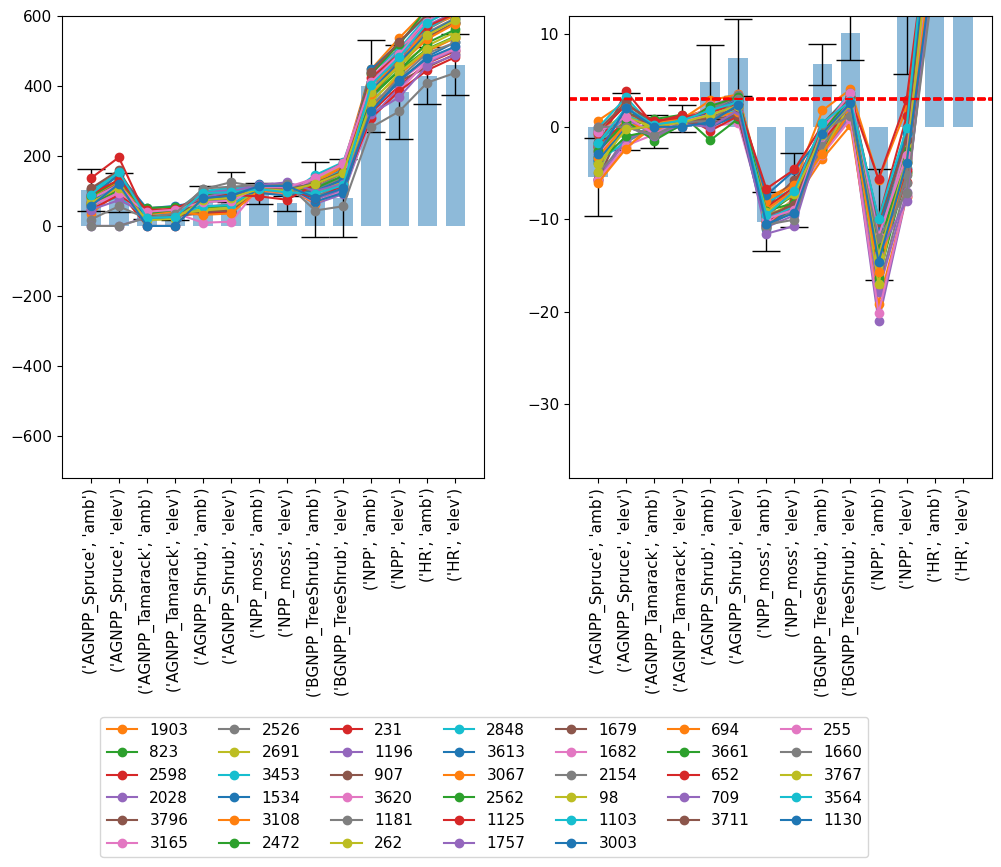

In [8]:
#fig, ax = plt.subplots(figsize = (12, 12))
#ax.plot(rmse_mean, rmse_slope, 'o')
#ax.set_xlim([0,2])
#ax.set_ylim([0,2])
#best_inds = [225,1222,3000]
fig, axes = plt.subplots(1, 2, figsize = (12, 6), sharex = True)
for i, bi in enumerate(best_inds):
    compare = pd.DataFrame({
        'obs_mean': obs_mean[0, :], 
        'obs_mean_std': obs_mean_std[0, :], 
        'sim_mean': sim_mean[bi, :],
        'obs_slope': obs_slope[0, :],
        'obs_slope_std': obs_slope_std[0, :],
        'sim_slope': sim_slope[bi, :]
    }, index = pd.MultiIndex.from_tuples([(var,co2) for var in VAR_SUBSET for co2 in ['amb', 'elev']]))

    # print(compare)

    ax = axes[0]
    if i == 0:
        ax.bar(np.arange(compare.shape[0]), compare['obs_mean'], width = 0.7, alpha = 0.5)
        he = ax.errorbar(np.arange(compare.shape[0]), compare['obs_mean'], 
                         yerr = compare['obs_mean_std'],
                         lw = 0, ecolor = 'k', elinewidth = 1, capsize = 10, barsabove = True)

    ax.plot(np.arange(compare.shape[0]), compare['sim_mean'], '-o', label = bi+1)
    ax.set_xticks(np.arange(compare.shape[0]))
    ax.set_xticklabels(compare.index, rotation = 90)
    ax.set_ylim([-720, 600])

    ax = axes[1]
    if i == 0:
        ax.bar(np.arange(compare.shape[0]), compare['obs_slope'], width = 0.7, alpha = 0.5)
        he = ax.errorbar(np.arange(compare.shape[0]), compare['obs_slope'], 
                         yerr = compare['obs_slope_std'],
                         lw = 0, ecolor = 'k', elinewidth = 1, capsize = 10, barsabove = True)
    ax.plot(np.arange(compare.shape[0]), compare['sim_slope'], '-o', label = bi+1)
    ax.set_xticks(np.arange(compare.shape[0]))
    ax.set_xticklabels(compare.index, rotation = 90)
    ax.set_ylim([-38, 12])
    ax.axhline(3, ls = '--', color = 'r')
    # ax.set_ylim([0,5])
ax.legend(ncol = min(7,int(np.ceil(n_best_ind / 2))), bbox_to_anchor = (-0.2, -0.5),
          loc = 'upper center')

# In round 1, use the best performance on Shrub, and let the rest adjust ...

3067 UQ_20231118 1.6058501003728596
1485 UQ_20240107 1.8219343122858924
1944 UQ_20240112 1.540019865776873
827 UQ_20240113 1.5443373933566353


/tmp/ipykernel_28007/2751474987.py:105: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend([h1] + h2, ['Obs'] + ['_'.join(p.split('_')[1:]) for p in prefix_list],
/tmp/ipykernel_28007/2751474987.py:105: UserWarning: Legend does not support handles for NoneType instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend([h1] + h2, ['Obs'] + ['_'.join(p.split('_')[1:]) for p in prefix_list],
/tmp/ipykernel_28007/2751474987.py:105: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax.legend([h1] + h2, ['Obs'] + ['_'.join(p.split('_')[1:]) for p in prefix_list],
/tmp/ipykern

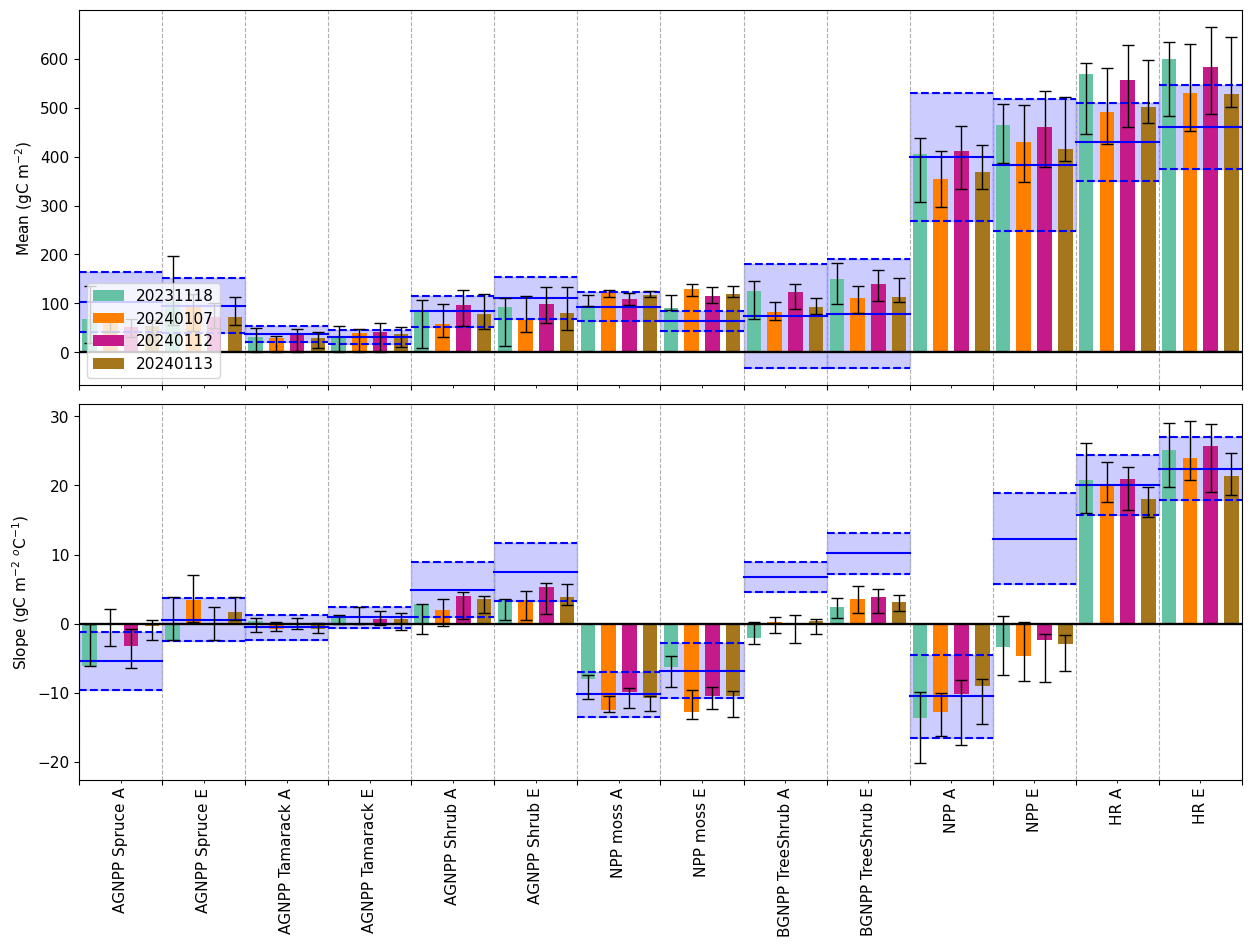

In [9]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
xticklabels = [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET for co2 in ['A', 'E']]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

#
npre = len(prefix_list)

#
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 1].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 3].reshape(1,-1)
n_best_ind = 20

## scale NPP & HR to 1/5
##obs_mean[:, -4:] = obs_mean[:, -4:] / 5
##obs_mean_std[:, -4:] = obs_mean_std[:, -4:] / 5
##obs_slope[:, -4:] = obs_slope[:, -4:] / 5
##obs_slope_std[:, -4:] = obs_slope_std[:, -4:] / 5

#
fig, axes = plt.subplots(2, 1, figsize = (15, 10), sharex = True)
fig.subplots_adjust(hspace = 0.05)
ax = axes[0]
#h1 = ax.bar(np.arange(0, obs_mean.shape[1]*npre, npre+1), obs_mean[0, :], width = 0.7,
#            color = ['#636363', '#969696'] * len(VAR_SUBSET))
#he = ax.errorbar(np.arange(0, obs_mean.shape[1]*4, len(prefix_list)+1), obs_mean[0, :], 
#                 yerr = obs_mean_std[0, :], lw = 0, ecolor = 'b', elinewidth = 1, 
#                 capsize = 4, barsabove = True)
for p in np.arange(0, obs_mean.shape[1]):
    h1, = ax.plot([p*npre-0.5, p*npre+npre-0.5], [obs_mean[0, p], obs_mean[0,p]], color = 'b')
    ax.plot([p*npre-0.5, p*npre+npre-0.5], [obs_mean[0, p] - obs_mean_std[0,p], 
                                 obs_mean[0,p] - obs_mean_std[0,p]], color = 'b', ls = '--')
    ax.plot([p*npre-0.5, p*npre+npre-0.5], [obs_mean[0, p] + obs_mean_std[0,p], 
                                 obs_mean[0,p] + obs_mean_std[0,p]], color = 'b', ls = '--')
    ax.fill_between([p*npre-0.5, p*npre+npre-0.5], obs_mean[0, p] - obs_mean_std[0, p], 
                    obs_mean[0, p] + obs_mean_std[0, p], color = 'b', 
                    alpha = 0.2)

ax.set_ylabel('Mean (gC m$^{-2}$)')
ax = axes[1]
#h1 = ax.bar(np.arange(0, obs_slope.shape[1]*npre, npre+1), obs_slope[0, :], width = 0.7,
#            color = ['#636363', '#969696'] * len(VAR_SUBSET))
#ax.errorbar(np.arange(0, obs_slope.shape[1]*4, len(prefix_list)+1), obs_slope[0, :], 
#            yerr = obs_slope_std[0, :], lw = 0, 
#            ecolor = 'b', elinewidth = 1, capsize = 4, barsabove = True)
for p in np.arange(0, obs_slope.shape[1]):
    h1 = ax.plot([p*npre-0.5, p*npre+npre-0.5], [obs_slope[0, p], obs_slope[0,p]], color = 'b')
    ax.plot([p*npre-0.5, p*npre+npre-0.5], [obs_slope[0, p] - obs_slope_std[0,p], 
                                 obs_slope[0,p] - obs_slope_std[0,p]], color = 'b', ls = '--')
    ax.plot([p*npre-0.5, p*npre+npre-0.5], [obs_slope[0, p] + obs_slope_std[0,p], 
                                 obs_slope[0,p] + obs_slope_std[0,p]], color = 'b', ls = '--')
    ax.fill_between([p*npre-0.5, p*npre+npre-0.5], obs_slope[0, p] - obs_slope_std[0, p], 
                    obs_slope[0, p] + obs_slope_std[0, p], color = 'b', 
                    alpha = 0.2)

ax.set_ylabel('Slope (gC m$^{-2}$ $^o$C$^{-1}$)')
#clist = ['#FF0000', '#00FFFF', '#FFFF00']
clist = ['#66c2a5', '#ff7f00', '#c51b8a', '#a6761d', '#0047AB']
h2 = [None] * len(prefix_list)
h3 = [None] * len(prefix_list)
for p, prefix in enumerate(prefix_list):

    # the 2 is ACO2 and ECO2
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    ## scale down NPP and HR to 1/5
    #sim_mean[:, -npre:] = sim_mean[:, -npre:] / 5
    #sim_slope[:, -npre:] = sim_slope[:, -npre:] / 5

    # find the best runs
    rmse_weights = np.repeat(np.array([1, 1, 1, 1, 1, 1, 1]), 2).reshape(1,-1)
    #rmse_mean = np.mean((np.abs(sim_mean - obs_mean) / np.abs(obs_mean))*rmse_weights, axis = 1)
    #rmse_slope = np.mean((np.abs(sim_slope - obs_slope) / np.abs(obs_slope))*rmse_weights, axis = 1)
    rmse_mean = np.mean((np.abs(sim_mean - obs_mean) / obs_mean_std)*rmse_weights, axis = 1)
    rmse_slope = np.mean((np.abs(sim_slope - obs_slope) / obs_slope_std)*rmse_weights, axis = 1)
    rmse_tot = rmse_mean + rmse_slope
    if n_best_ind >= len(rmse_tot):
        best_inds = range(n_best_ind)
    else:
        best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]
    single_best_ind = np.nanargmin(rmse_tot)
    print(single_best_ind+1, prefix, rmse_tot[single_best_ind])

    sim_mean_bi = sim_mean[best_inds, :]
    sim_slope_bi = sim_slope[best_inds, :]

    ax = axes[0]
    h2[p] = ax.bar(np.arange(p, sim_mean.shape[1]*npre, npre),
                   sim_mean[single_best_ind, :], color = clist[p], width = 0.7)
    ax.errorbar(np.arange(p, sim_mean_bi.shape[1]*npre, npre), 
                sim_mean[single_best_ind, :], 
                yerr = np.abs(np.vstack([np.min(sim_mean_bi, axis = 0), 
                                         np.max(sim_mean_bi, axis = 0)]) - \
                              sim_mean[single_best_ind, :]),
                lw = 0, ecolor = 'k', elinewidth = 1, 
                capsize = 4, barsabove = True)
    ax.legend([h1] + h2, ['Obs'] + ['_'.join(p.split('_')[1:]) for p in prefix_list],
            loc = 'lower left')
    ax.set_xticks(np.arange(-0.5, sim_mean_bi.shape[1]*npre, npre)) 
    ax.set_xticks(np.arange(1.5, sim_mean_bi.shape[1]*npre, npre), minor=True)
    ax.set_xticklabels([])
    ax.set_xticklabels(xticklabels, rotation = 90, minor=True)
    #ax.set_ylim([-780, 600])
    ax.grid(True, axis = 'x', ls = '--')
    ax.set_xlim([-0.5, sim_mean_bi.shape[1]*4])
    ax.axhline(0, color = 'k')

    ax = axes[1]
    h2[p] = ax.bar(np.arange(p, sim_slope.shape[1]*npre, npre),
                    sim_slope[single_best_ind, :], color = clist[p], width = 0.7)
    ax.errorbar(np.arange(p, sim_slope_bi.shape[1]*npre, npre), 
                sim_slope[single_best_ind, :], 
                yerr = np.abs(np.vstack([np.min(sim_slope_bi, axis = 0), 
                                         np.max(sim_slope_bi, axis = 0)]) - \
                              sim_slope[single_best_ind, :]),
                lw = 0, ecolor = 'k', elinewidth = 1, 
                capsize = 4, barsabove = True)
    ax.set_xticks(np.arange(-0.5, sim_slope_bi.shape[1]*npre, npre)) 
    ax.set_xticks(np.arange(1.5, sim_slope_bi.shape[1]*npre, npre), minor=True)
    ax.set_xticklabels([])
    ax.set_xticklabels(xticklabels, rotation = 90, minor=True)
    #ax.set_ylim([-38, 12])
    ax.grid(True, axis = 'x', ls = '--')
    ax.set_xlim([-0.5, sim_slope_bi.shape[1]*npre-0.5])
    ax.axhline(0, color = 'k')

Text(0.5, 1.0, 'Number of variables inside observed uncertainty')

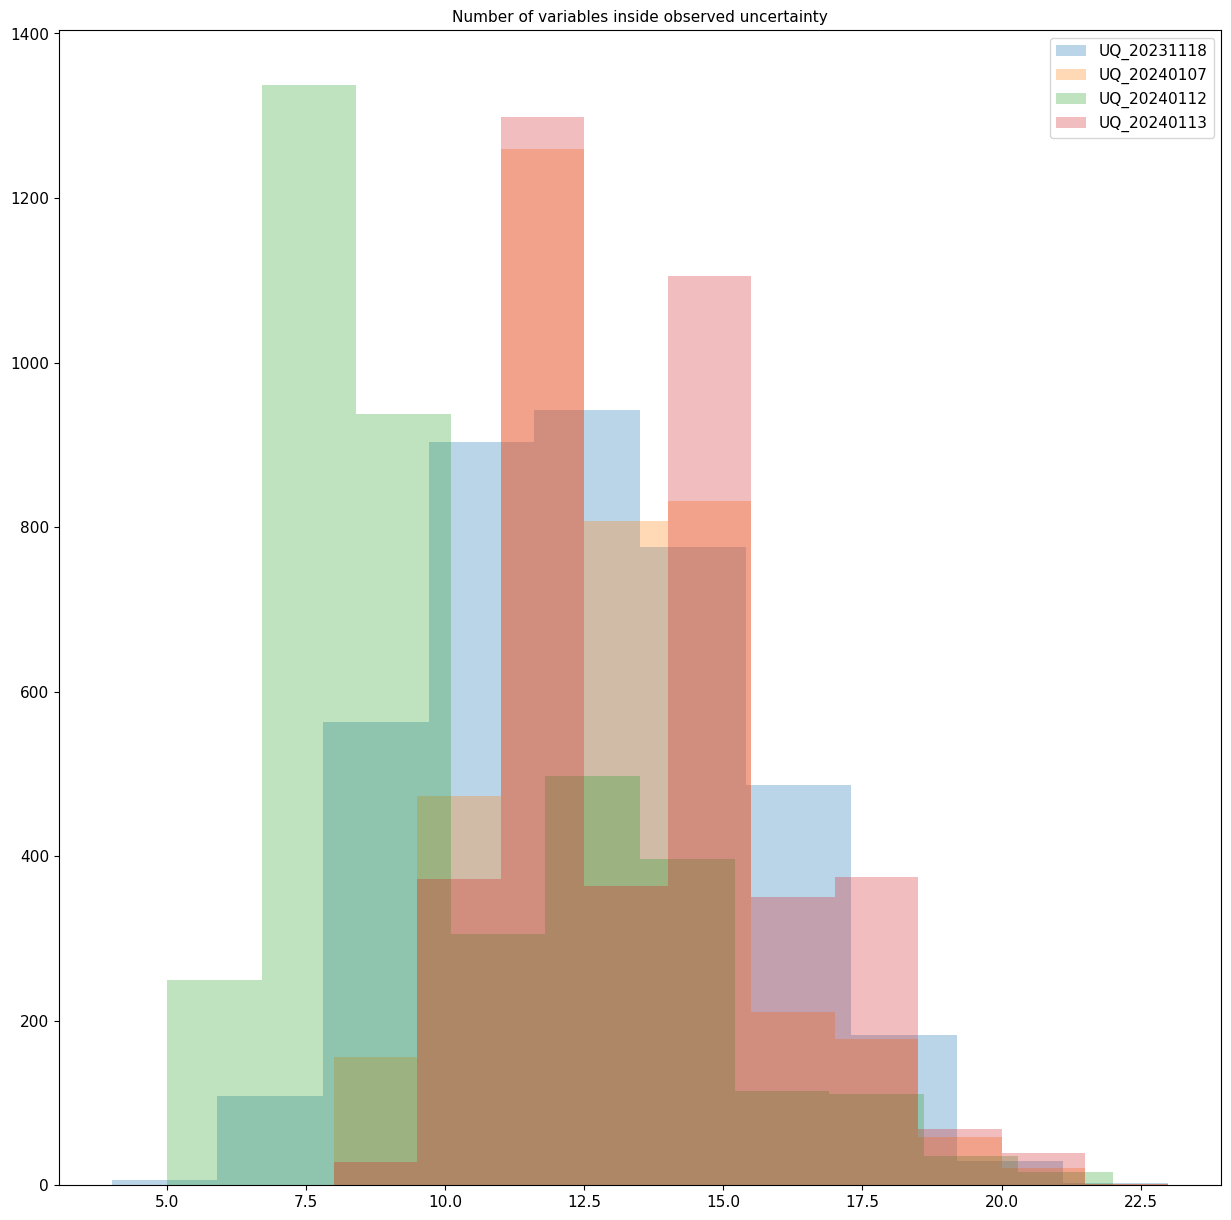

In [10]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
xticklabels = [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET for co2 in ['A', 'E']]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

#
npre = len(prefix_list)

#
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 1].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 3].reshape(1,-1)

#
rmse_weights = np.repeat(np.array([1, 1, 1, 1, 1, 1, 1]), 4).reshape(1,-1)

#
fig, ax = plt.subplots(figsize = (15, 15))
for i, prefix in enumerate(prefix_list):
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    temp = np.concatenate(
        [(sim_mean < (obs_mean + obs_mean_std)) & (sim_mean > (obs_mean - obs_mean_std)),
         (sim_slope < (obs_slope + obs_slope_std)) & (sim_slope > (obs_slope - obs_slope_std))],
        axis = 1
    )

    temp = temp * rmse_weights

    ax.hist(np.sum(temp, axis = 1), alpha = 0.3, label = prefix)
ax.legend()
ax.set_title('Number of variables inside observed uncertainty')

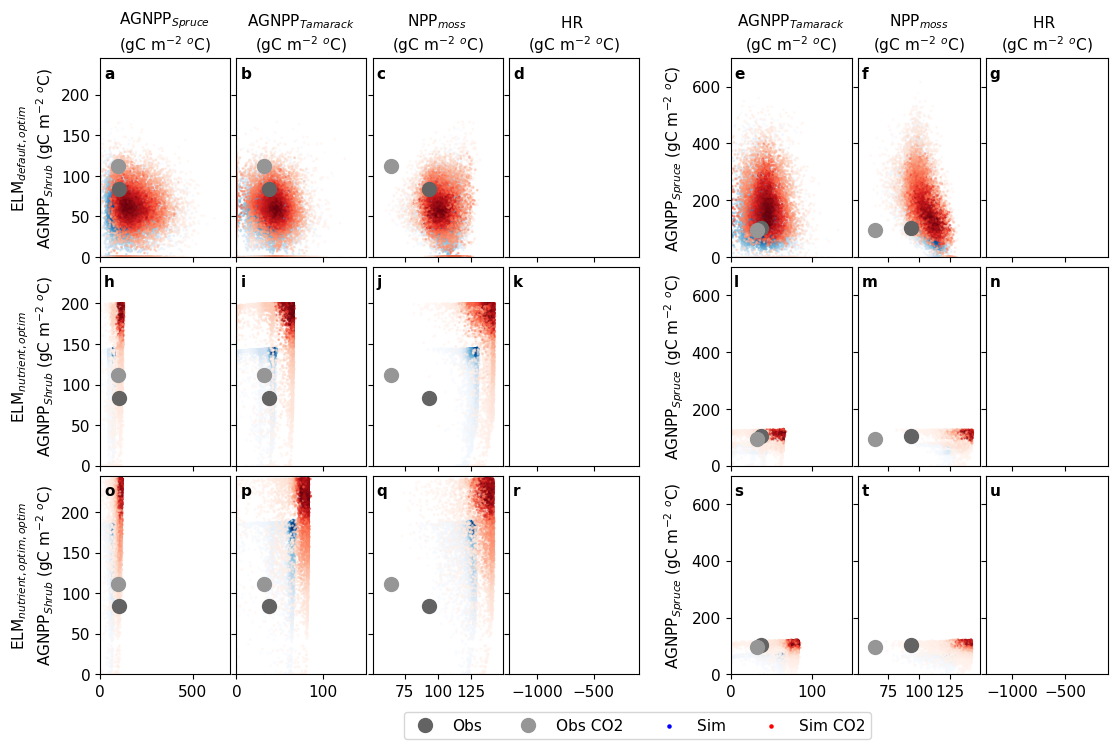

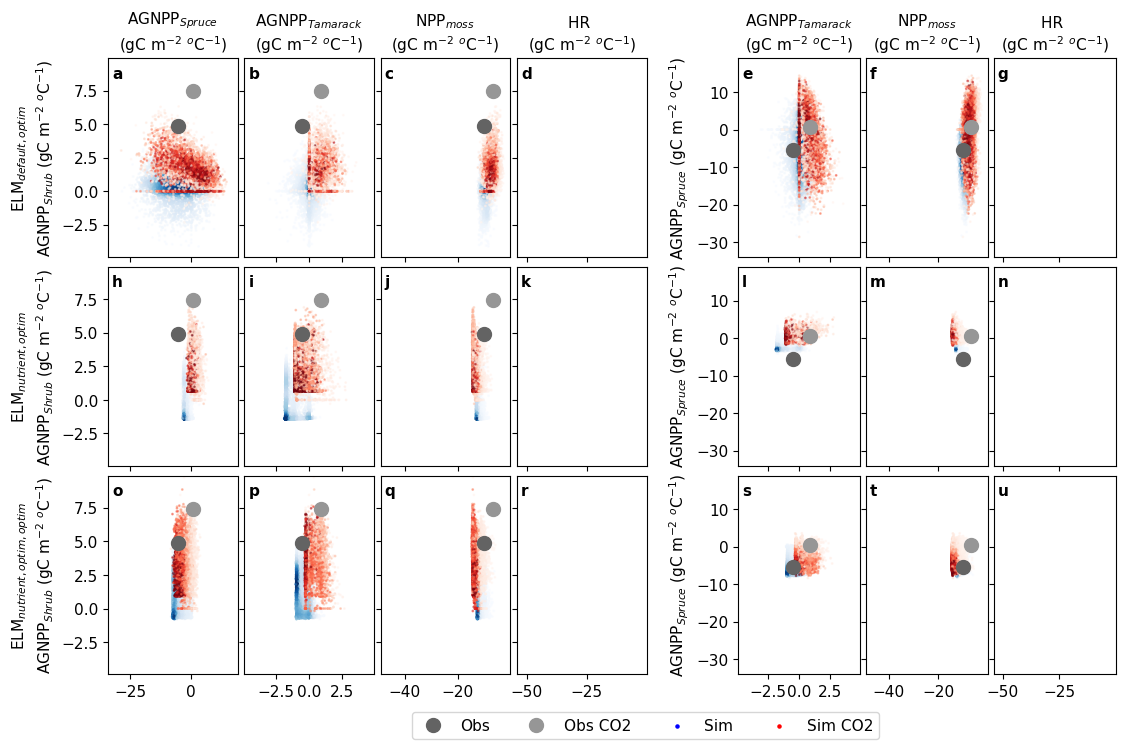

In [11]:
# Across the sensitivity parameters, check relationship between the temperature
# sensitivity of AGNPP spruce and AGNPP shrub
name_list = ['ELM$_{default,optim}$', # 'ELM$_{default}$', 
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
varx_list = ['AGNPP_Spruce', 'AGNPP_Tamarack', 'NPP_moss', 'HR', 
             'AGNPP_Tamarack', 'NPP_moss', 'HR']
vary_list = ['AGNPP_Shrub', 'AGNPP_Shrub', 'AGNPP_Shrub', 'AGNPP_Shrub',
             'AGNPP_Spruce', 'AGNPP_Spruce', 'AGNPP_Spruce']

var_range_list = {
    0: {'AGNPP_Spruce': (0,700), 'AGNPP_Tamarack': (0, 150), 'AGNPP_Shrub': (0, 245), 
        'NPP_moss': (51, 149), 'HR': (-1249, -101)},
    2: {'AGNPP_Spruce': (-34,19), 'AGNPP_Tamarack': (-4.9, 4.9), 'AGNPP_Shrub': (-4.9, 9.9), 
        'NPP_moss': (-49, -0.1), 'HR': (-54, -0.1)}
}

labs = 'abcdefghijklmnopqrstuvwxyz'

for ind_statistic in [0,2]:

    # Create the grid arrangement
    fig = plt.figure(figsize=(13, 8))

    outer_grid = gridspec.GridSpec(1, 2, width_ratios=[10, 7], wspace=0.2)
    left_grid = gridspec.GridSpecFromSubplotSpec(3, 4, subplot_spec=outer_grid[0],
                                                 wspace=0.05, hspace=0.05)
    right_grid = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=outer_grid[1],
                                                  wspace=0.05, hspace=0.05)

    axes = np.empty([3, len(varx_list)], dtype = object)
    for i,j in it.product(range(3), range(4)):
        axes[i,j] = fig.add_subplot(left_grid[i, j])
    for i,j in it.product(range(3), range(3)):
        axes[i,j+4] = fig.add_subplot(right_grid[i, j])

    for i, (prefix, name) in enumerate(zip(prefix_list, name_list)):
        #for j, (varx, vary, ind_statistic, (ymin,ymax)) in \
        #    enumerate(zip(varx_list, vary_list, ind_stat_list, yrng_list)):
        for j, (varx, vary) in enumerate(zip(varx_list, vary_list)):

            indx = np.where([var == varx for var in VAR_LIST])[0][0]
            indy = np.where([var == vary for var in VAR_LIST])[0][0]
            xmin, xmax = var_range_list[ind_statistic][varx]
            ymin, ymax = var_range_list[ind_statistic][vary]

            ax = axes[i,j]

            # the 2 is ACO2 and ECO2
            obs_x = collection_obs.values.reshape(-1, 2, 4)[indx, :, ind_statistic]
            obs_y = collection_obs.values.reshape(-1, 2, 4)[indy, :, ind_statistic]
            h1, = ax.plot(obs_x[0], obs_y[0], 'o', markersize = 10, color = '#636363',
                          markerfacecolor = '#636363', zorder = 3)
            h2, = ax.plot(obs_x[1], obs_y[1], 'o', markersize = 10, color = '#969696',
                          markerfacecolor = '#969696', zorder = 3)

            sim_x = collection_sim[prefix][:, indx, :, ind_statistic].reshape(-1, 2)
            sim_y = collection_sim[prefix][:, indy, :, ind_statistic].reshape(-1, 2)

            xy = np.vstack([sim_x[:,0], sim_y[:,0]])
            z0 = gaussian_kde(xy)(xy)
            h3 = ax.scatter(sim_x[:,0], sim_y[:,0], c = z0, s = 1, cmap = 'Blues', alpha = 0.5)
            xy = np.vstack([sim_x[:,1], sim_y[:,1]])
            z1 = gaussian_kde(xy)(xy)
            h4 = ax.scatter(sim_x[:,1], sim_y[:,1], c = z0, s = 1, cmap = 'Reds', alpha = 0.5)
            #print(np.min(sim_x, axis = 0), np.max(sim_x, axis = 0), np.min(sim_y, axis = 0), 
            #      np.max(sim_y, axis = 0))

            if '_' in vary:
                ylabel = vary.replace("_", "$_{")+'}$'
            else:
                ylabel = vary
            if ind_statistic == 2:
                ylabel = ylabel + ' (gC m$^{-2}$ $^o$C$^{-1}$)'
            else:
                ylabel = ylabel + ' (gC m$^{-2}$ $^o$C)'
            if j == 0:
                ax.set_ylabel(name + '\n' + ylabel)
            elif j == 4:
                ax.set_ylabel(ylabel)
            else:
                ax.set_yticklabels([])

            if '_' in varx:
                xlabel = varx.replace("_", "$_{")+'}$'
            else:
                xlabel = varx
            if ind_statistic == 2:
                xlabel = xlabel + ' \n(gC m$^{-2}$ $^o$C$^{-1}$)'
            else:
                xlabel = xlabel + ' \n(gC m$^{-2}$ $^o$C)'
            if i == 0:
                ax.set_title(xlabel)
            if i != 2:
                ax.set_xticklabels([])

            ax.set_xlim([xmin, xmax])
            ax.set_ylim([ymin, ymax])

            if (i == 2) and (j == 0):
                h3 = ax.scatter(np.nan, np.nan, c = 'b', s = 5)
                h4 = ax.scatter(np.nan, np.nan, c = 'r', s = 5)
                ax.legend([h1, h2, h3, h4], ['Obs', 'Obs CO2', 'Sim', 'Sim CO2'],
                          bbox_to_anchor = (6, -0.15), ncol = 4) # handletextpad = 0.5, 

            ax.text(0.03, 0.9, labs[i*len(varx_list)+j], transform = ax.transAxes,
                    fontdict = {'weight': 'bold'})

## Do more single run checks on parameter relationships

In [12]:
dummy()

NameError: name 'dummy' is not defined

In [ ]:
# Tamarack's AGNPP and TOTVEGC

prefix = 'UQ_20231113_2a'
N = 768

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][:, 4, i, 0]
    mean_anpp_obs = collection_obs.loc[('ANPP_lala',co2), 'mean']
    mean_totvegc_abg = collection_sim[prefix][:, 1, i, 0]
    mean_totvegc_abg_obs = collection_obs.loc[('TOTVEGC_ABG_lala',co2), 'mean']

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg, mean_anpp, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_totvegc_abg_obs,  mean_anpp_obs, 'o', color = 'b', label = 'Obs')

    distance[co2] = \
        np.sqrt( np.power((mean_totvegc_abg - mean_totvegc_abg_obs) / \
                          collection_obs.loc['TOTVEGC_ABG_lala', 'mean'].mean(), 2) \
                + np.power((mean_anpp - mean_anpp_obs) / \
                           collection_obs.loc['ANPP_lala', 'mean'].mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][best, 4, i, 0]
    mean_totvegc_abg = collection_sim[prefix][best, 1, i, 0]

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg,  mean_anpp, 'o', color = 'k', label = 'Best')
    ax.set_xlabel('Tamarack TOTVEGC_ABG (gC m-2)')
    ax.set_ylabel('Tamarack ANPP (gC m-2 year-1)')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

In [ ]:
# Shrub's AGNPP and HR

prefix = 'UQ_20240312_test20241025'

ind_y = 8
name_y = 'AGNPP_Shrub'
unit_y = 'gC m-2 year-1'
ind_x = -2
name_x = 'HR'
unit_x = 'gC m-2 year-1'

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][:, ind_y, i, 0]
    mean_y_obs = collection_obs.loc[(name_y,co2), 'mean']
    mean_x = collection_sim[prefix][:, ind_x, i, 0]
    mean_x_obs = collection_obs.loc[(name_x,co2), 'mean']
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_x_obs,  mean_y_obs, 'o', color = 'b', label = 'Obs')
    ax.legend()

    distance[co2] = \
        np.sqrt( np.power((mean_x - mean_x_obs) / mean_x_obs.mean(), 2) \
                + np.power((mean_y - mean_y_obs) / mean_y_obs.mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][best, ind_y, i, 0]
    mean_x = collection_sim[prefix][best, ind_x, i, 0]
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'k', label = 'Best')
    ax.set_xlabel(f'{name_x} {unit_x}')
    ax.set_ylabel(f'{name_y} {unit_y}')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

In [ ]:
# Shrub's AGNPP and HR

prefix = 'UQ_20240312_test20241017'

ind_y = 8
name_y = 'AGNPP_Shrub'
unit_y = 'gC m-2 year-1 $^o$C-1'
ind_x = -2
name_x = 'HR'
unit_x = 'gC m-2 year-1 $^o$C-1'

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][:, ind_y, i, 2]
    mean_y_obs = collection_obs.loc[(name_y,co2), 'slope']
    mean_x = collection_sim[prefix][:, ind_x, i, 2]
    mean_x_obs = collection_obs.loc[(name_x,co2), 'slope']
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_x_obs,  mean_y_obs, 'o', color = 'b', label = 'Obs')
    ax.legend()

    distance[co2] = \
        np.sqrt( np.power((mean_x - mean_x_obs) / mean_x_obs.mean(), 2) \
                + np.power((mean_y - mean_y_obs) / mean_y_obs.mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][best, ind_y, i, 2]
    mean_x = collection_sim[prefix][best, ind_x, i, 2]
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'k', label = 'Best')
    ax.set_xlabel(f'{name_x} {unit_x}')
    ax.set_ylabel(f'{name_y} {unit_y}')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

In [ ]:
prefix = 'UQ_20240312_test20241017'
N = 3125

# Tree to shrub ratios
spruce_npp = collection_sim[prefix][:, 6, :, 0].mean(axis = 1)
tamarack_npp = collection_sim[prefix][:, 7, :, 0].mean(axis = 1)
shrub_npp = collection_sim[prefix][:, 8, :, 0].mean(axis = 1)
tree_shrub_ratio =  tamarack_npp / shrub_npp

# BGNPP/AGNPP
bg_ag_ratio = collection_sim[prefix][:, -3, :, 0].mean(axis = 1)

# The sensitivity of AGNPP to temperature
spruce_sensitivity = collection_sim[prefix][:, 6, :, 2].mean(axis = 1)
tamarack_sensitivity = collection_sim[prefix][:, 7, :, 2].mean(axis = 1)
shrub_sensitivity = collection_sim[prefix][:, 8, :, 2].mean(axis = 1)
bgnpp_sensitivity = collection_sim[prefix][:, -3, :, 2].mean(axis = 1)

# HR & NEE level
hr = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_mean = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_sensitivity = collection_sim[prefix][:, -2, :, 2].mean(axis = 1)
nee = collection_sim[prefix][:, -1, :, 0].mean(axis = 1)
nee_sensitivity = collection_sim[prefix][:, -1, :, 2].mean(axis = 1)

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

In [ ]:
# without PFT-specific sizing, there is no result what so ever
q10_collect = get_params(prefix, 'q10_uptake', N)
q10_ratio = q10_collect[:,11] / q10_collect[:,2:3].mean(axis = 1)

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)

ax = axes.flat[0]
ax.plot(q10_ratio, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(q10_ratio, tamarack_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(q10_ratio, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(q10_ratio, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

ax = axes.flat[4]
ax.plot(q10_ratio, hr, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of heterotrophic respiration')

ax = axes.flat[5]
ax.plot(q10_ratio, nee, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of NEE')

ax = axes.flat[6]
ax.plot(q10_ratio, hr_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of HR to warming')

ax = axes.flat[7]
ax.plot(q10_ratio, nee_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of NEE to warming')

In [ ]:
km_froot_n = get_params(prefix, 'km_froot_n', N)
km_froot_n = km_froot_n[:, 0]

fungi_cost_n = get_params(prefix, 'fungi_cost_n', N)
fungi_cost_n = fungi_cost_n[:, 0]

vmax_froot_n = get_params(prefix, 'vmax_froot_n', N)
vmax_froot_n = vmax_froot_n[:,11]

vmax_fungi_son = get_params(prefix, 'vmax_fungi_son', N)
vmax_fungi_son = vmax_fungi_son[:,11]

In [ ]:
#for varname, var in zip(
#    ['km_froot_n', 'fungi_cost_n'], 
#    [km_froot_n, fungi_cost_n]
#):
for varname, var in zip(
    ['vmax_froot_n', 'vmax_fungi_son'],
    [vmax_froot_n, vmax_fungi_son]
):
    fig, axes = plt.subplots(2, 2, figsize = (16, 8))

    ax = axes.flat[0]
    ax.plot(var, shrub_npp, 'o', ms = 1)
    ax.set_xlabel(varname)
    ax.set_ylabel('shrub NPP')
    xnew, ynew, slope, intercept, r2 = fit_line(var, shrub_npp)
    ax.plot(xnew, intercept + xnew * slope, '-k')

    ax = axes.flat[1]
    #response = shrub_sensitivity / shrub_npp
    #rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
    response = shrub_sensitivity
    rname = 'Sensitivity of shrub AGNPP to temperature'
    ax.plot(var, response, 'o', ms = 1)
    ax.set_ylabel(rname)
    xnew, ynew, slope, intercept, r2 = fit_line(var, response)
    ax.plot(xnew, intercept + xnew * slope, '-k')
    ax.set_xlabel(varname)

    ax = axes.flat[2]
    ax.plot(var, hr_mean, 'o', ms = 1)
    ax.set_xlabel(varname)
    ax.set_ylabel('Mean HR')
    xnew, ynew, slope, intercept, r2 = fit_line(var, hr_mean)
    ax.plot(xnew, intercept + xnew * slope, '-k')

    ax = axes.flat[3]
    ax.plot(var, hr_sensitivity, 'o', ms = 1)
    ax.set_xlabel(varname)
    ax.set_ylabel('Sensitivity of HR to temperature')
    xnew, ynew, slope, intercept, r2 = fit_line(var, hr_sensitivity)
    ax.plot(xnew, intercept + xnew * slope, '-k')

In [ ]:
# Colorized plot
varname = 'vmax_froot_n'
var = vmax_froot_n

for varc_name, varcolor in zip(
     ['km_froot_n', 'fungi_cost_n'], 
    [km_froot_n, fungi_cost_n]
):
    fig, axes = plt.subplots(2, 2, figsize = (16, 8))

    ax = axes.flat[0]
    cf = ax.scatter(var, shrub_npp, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_xlabel(varname)
    ax.set_ylabel('shrub NPP')
    plt.colorbar(cf, ax = ax, label = varc_name)

    ax = axes.flat[1]
    #response = shrub_sensitivity / shrub_npp
    #rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
    response = shrub_sensitivity
    rname = 'Sensitivity of shrub AGNPP to temperature'
    cf = ax.scatter(var, response, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_ylabel(rname)
    ax.set_xlabel(varname)
    plt.colorbar(cf, ax = ax, label = varc_name)

    ax = axes.flat[2]
    cf = ax.scatter(var, hr_mean, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_xlabel(varname)
    ax.set_ylabel('Mean HR')
    plt.colorbar(cf, ax = ax, label = varc_name)

    ax = axes.flat[3]
    cf = ax.scatter(var, hr_sensitivity, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_xlabel(varname)
    ax.set_ylabel('Sensitivity of HR to temperature')
    plt.colorbar(cf, ax = ax, label = varc_name)

In [ ]:
# Colorized plot of ratios
varname_x = 'log(km_froot_n / vmax_froot_n)'
var_x = np.log(km_froot_n / vmax_froot_n)
varname_y = 'log(fungi_cost_n / vmax_froot_n)'
var_y = np.log(fungi_cost_n / vmax_froot_n)

fig, axes = plt.subplots(2, 2, figsize = (16, 8))

ax = axes.flat[0]
cf = ax.scatter(var_x, shrub_npp, s = 1, c = var_y, cmap = 'Spectral')
ax.set_xlabel(varname_x)
ax.set_ylabel('shrub NPP')
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[1]
#response = shrub_sensitivity / shrub_npp
#rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
response = shrub_sensitivity
rname = 'Sensitivity of shrub AGNPP to temperature'
cf = ax.scatter(var_x, response, s = 1, c = var_y, cmap = 'Spectral')
ax.set_ylabel(rname)
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[2]
cf = ax.scatter(var_x, hr_mean, s = 1, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Mean HR')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[3]
cf = ax.scatter(var_x, hr_sensitivity, s = 1, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Sensitivity of HR to temperature')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

In [ ]:
# What does the joint distribution of vmax_froot_n & vmax_fungi_son look like?
prefix = 'UQ_20240312_test20241012'
N = 100

# Tree to shrub ratios
spruce_npp = collection_sim[prefix][:, 6, :, 0].mean(axis = 1)
tamarack_npp = collection_sim[prefix][:, 7, :, 0].mean(axis = 1)
shrub_npp = collection_sim[prefix][:, 8, :, 0].mean(axis = 1)
tree_shrub_ratio =  tamarack_npp / shrub_npp

# BGNPP/AGNPP
bg_ag_ratio = collection_sim[prefix][:, -3, :, 0].mean(axis = 1)

# The sensitivity of AGNPP to temperature
spruce_sensitivity = collection_sim[prefix][:, 6, :, 2].mean(axis = 1)
tamarack_sensitivity = collection_sim[prefix][:, 7, :, 2].mean(axis = 1)
shrub_sensitivity = collection_sim[prefix][:, 8, :, 2].mean(axis = 1)
bgnpp_sensitivity = collection_sim[prefix][:, -3, :, 2].mean(axis = 1)

# HR & NEE level
hr = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_mean = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_sensitivity = collection_sim[prefix][:, -2, :, 2].mean(axis = 1)
nee = collection_sim[prefix][:, -1, :, 0].mean(axis = 1)
nee_sensitivity = collection_sim[prefix][:, -1, :, 2].mean(axis = 1)

vmax_froot_n = get_params(prefix, 'vmax_froot_n', N)
vmax_froot_n = vmax_froot_n[:,11]

vmax_fungi_son = get_params(prefix, 'vmax_fungi_son', N)
vmax_fungi_son = vmax_fungi_son[:,11]

In [ ]:
# Colorized plot of ratios
varname_x = 'vmax_froot_n'
var_x = vmax_froot_n
varname_y = 'vmax_fungi_son'
var_y = vmax_fungi_son

fig, axes = plt.subplots(2, 2, figsize = (16, 8))

ax = axes.flat[0]
cf = ax.scatter(var_x, shrub_npp, s = 5, c = var_y, cmap = 'Spectral')
ax.set_xlabel(varname_x)
ax.set_ylabel('shrub NPP')
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[1]
#response = shrub_sensitivity / shrub_npp
#rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
response = shrub_sensitivity
rname = 'Sensitivity of shrub AGNPP to temperature'
cf = ax.scatter(var_x, response, s = 5, c = var_y, cmap = 'Spectral')
ax.set_ylabel(rname)
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[2]
cf = ax.scatter(var_x, hr_mean, s = 5, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Mean HR')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[3]
cf = ax.scatter(var_x, hr_sensitivity, s = 5, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Sensitivity of HR to temperature')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

In [ ]:
# froot_leaf larger for trees means lower tree AGNPP compared to shrub
# especially for the evergreen. whereas froot_leaf larger for shrub has
# the opposite effect. Larger belowground allocation means lower 
# aboveground advantage, makes sense

# Evergreen is dominating the BG-to-AG ratio in the eventual result

alloccollect = get_params(prefix, 'froot_leaf', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], tree_shrub_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of tree AGNPP to shrub AGNPP')

    # observed level
    obs = collection_obs.loc['ANPPtree', 'mean'].mean() / \
        collection_obs.loc['ANPPshrub', 'mean'].mean()
    ax.axhline(obs, color = 'r', lw = 2)

# when shrub's ratio < 0.25, what does the tree AGNPP & shrub AGNPP compare to obs?


fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], bg_ag_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of BGNPP to AGNPP')

    # observed level
    obs = collection_obs.loc['BGNPP', 'mean'].mean() / \
        (collection_obs.loc['ANPPtree', 'mean'].mean() + \
        collection_obs.loc['ANPPshrub', 'mean'].mean()) 
    ax.axhline(obs, color = 'r', lw = 2)

In [ ]:
#alloccollect = get_params(prefix, 'froot_leaf_slope', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, (name,sens) in enumerate(zip(["tree","shrub","bg"],
                                    [tamarack_sensitivity, shrub_sensitivity,bgnpp_sensitivity])):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, 11], sens, 'o', ms = 1)
    ax.set_xlabel('froot_leaf_slope')
    ax.set_ylabel(f'{name} sensitivity')

## Find the parameter ranges for desired sensitivities and mean

In [ ]:
selected_runs = np.where(
    (shrub_sensitivity >= 0) & (tree_sensitivity < 0.0) & (bgnpp_sensitivity > -10)
)[0] + 1
print(selected_runs)

In [ ]:
params_collect = {}
for parname in ['froot_leaf', 'froot_leaf_slope', 'q10_uptake', 'kmin_nuptake', 'kmin_puptake', 
                'compet_pft_sminn', 'compet_pft_sminp', 'compet_pft_sminp', 
                'cpool_pft_sminn', 'cpool_pft_sminp']: # , 'alpha_fpg', 'alpha_fpg_p'
    parvals = get_params(prefix, parname, 2000, selected_runs)
    if parvals.shape[1] == 1:
        params_collect[parname] = parvals
    else:
        for pft in [2, 3, 11]:
            params_collect[f'{parname}_{pft}'] = parvals[:, pft]

params_list = list(params_collect.keys())
fig, axes = plt.subplots(2, int(np.ceil(len(params_collect) / 2)), figsize = (20, 10))
fig.subplots_adjust(wspace = 0.2)
for i in range(len(params_list)):
    ax = axes.flat[i]
    ax.boxplot(params_collect[params_list[i]])
    ax.set_ylabel(params_list[i], labelpad=0)